### Notbeook for testing the Divergence of a field

1) Subract the mean. 
2) calc Divergence of CMEMS
3) Calc Divergence 

In [155]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import xarray as xr 
from functions.funcs import *
from  Divergencecals import *
from functions.funcs import Rolling_mean

In [106]:
ds = xr.open_dataset('Data/krigging_field.nc')
target_date = pd.to_datetime("2024-6-12", format="%Y-%m-%d")
slice_t = ds.sel(time =target_date)
lons = slice_t.lon
lats = slice_t.lat

In [109]:
print(ds.lat)
print(ds.lon)

<xarray.DataArray 'lat' (lat: 42)> Size: 168B
array([4.416667, 4.5     , 4.583333, 4.666667, 4.75    , 4.833333, 4.916667,
       5.      , 5.083333, 5.166667, 5.25    , 5.333333, 5.416667, 5.5     ,
       5.583333, 5.666667, 5.75    , 5.833333, 5.916667, 6.      , 6.083333,
       6.166667, 6.25    , 6.333333, 6.416667, 6.5     , 6.583333, 6.666667,
       6.75    , 6.833333, 6.916667, 7.      , 7.083333, 7.166667, 7.25    ,
       7.333333, 7.416667, 7.5     , 7.583333, 7.666667, 7.75    , 7.833333],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 168B 4.417 4.5 4.583 4.667 ... 7.583 7.667 7.75 7.833
<xarray.DataArray 'lon' (lon: 42)> Size: 168B
array([-163.83333, -163.75   , -163.66667, -163.58333, -163.5    , -163.41667,
       -163.33333, -163.25   , -163.16667, -163.08333, -163.     , -162.91667,
       -162.83333, -162.75   , -162.66667, -162.58333, -162.5    , -162.41667,
       -162.33333, -162.25   , -162.16667, -162.08333, -162.     , -161.91667,
       -161.83

## With padding Derivative operators

residuals u,v : (np.float64(0.04461477831935888), np.float64(0.05626533466513764))
RMSE u , v : (np.float64(0.04475472959058798), np.float64(0.056332823951172506))
(42, 42)


Text(0.5, 0.98, 'Krigging field ')

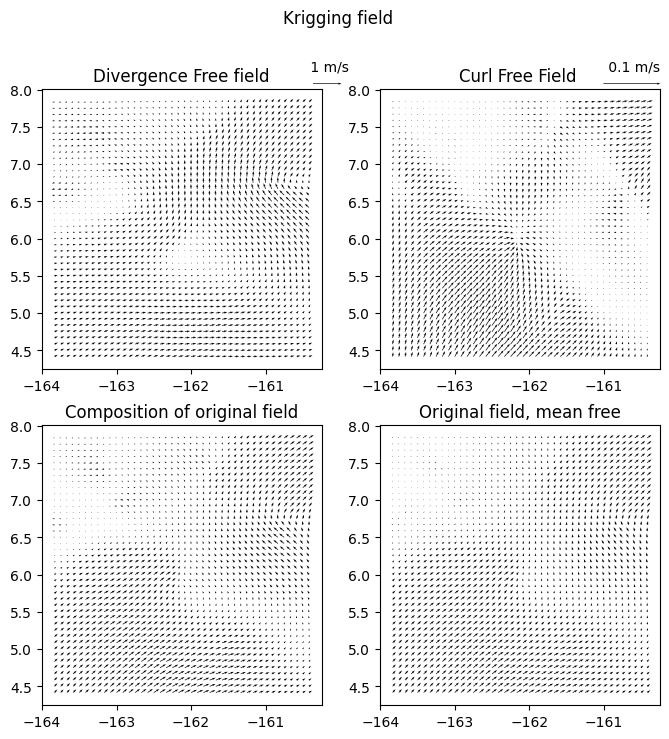

In [ ]:
dx = 1/12 #haversine_dist(6.1, 163, 6.1, 163 +1/12) *1000
### need to pad first. 
lin = 30
zeros = 10
u_p = padding(slice_t.uo.values, lin,zeros )
v_p = padding(slice_t.vo.values, lin,zeros)
u_df, v_df = divergencefree(u_p, v_p, dx ,dx)
u_cf, v_cf = Curlfree(u_p, v_p, dx ,dx)
u_recon = u_df + u_cf
v_recon = v_df + v_cf 

u_df = unpad(u_df, lin+zeros)
v_df = unpad(v_df, lin+zeros)
u_cf = unpad(u_cf, lin+zeros)
v_cf = unpad(v_cf, lin+zeros)
u_recon = unpad(u_recon, lin+zeros)
v_recon = unpad(v_recon, lin+zeros)

RMSE_u= np.sqrt(np.mean((slice_t.uo.values - u_recon)**2))
RMSE_v = np.sqrt(np.mean((slice_t.vo.values - v_recon)**2))

residu = np.mean(slice_t.uo.values - u_recon)
residv = np.mean(slice_t.vo.values - v_recon)
                  
print(f"residuals u,v : {residu, residv}")
print(f"RMSE u , v : {RMSE_u, RMSE_v}")
print(u_df.shape)
X, Y = np.meshgrid(lons, lats)
fig, axs = plt.subplots(2,2, figsize = (8,8))
q0 = axs[0,0].quiver(X,Y,u_df,v_df)
q1 = axs[0,1].quiver(X,Y,u_cf, v_cf)
q2 = axs[1,0].quiver(X,Y, u_recon, v_recon)
q3 = axs[1,1].quiver(X,Y, slice_t.uo, slice_t.vo)

axs[0,0].quiverkey(q0, 1.02, 1.02, 1, label = " 1 m/s", coordinates = "axes")
axs[0,1].quiverkey(q1, 0.9, 1.02, 1, label = " 0.1 m/s", coordinates = "axes")


axs[0,0].set_title("Divergence Free field")
axs[0,1].set_title("Curl Free Field ")
axs[1,0].set_title("Composition of original field")
axs[1,1].set_title("Original field, mean free")

axs[0,0].set_box_aspect(1)
axs[0,1].set_box_aspect(1)
axs[1,0].set_box_aspect(1)
axs[1,1].set_box_aspect(1)
fig.suptitle("Krigging field ")

## FFT method 

In [ ]:
import numpy as np

def divergence(u, v, dx, dy, field = False, mean = True):
    du_dx = np.gradient(u, dx, axis=1)
    dv_dy = np.gradient(v, dy, axis=0)
    if field == True: 
        return du_dx + dv_dy
    return np.abs((du_dx + dv_dy)).mean()

def vorticity(u,v,dx, dy, field = False): 
    dv_dx = np.gradient(v,dx, axis =1 )
    du_dy = np.gradient(u,dy, axis =1)
    if field == True: 
        return dv_dx - du_dy
    return np.abs((dv_dx - du_dy)).mean()


def helmholtz_div_free(u, v, dx, dy):
    from scipy.fft import fft2, ifft2, fftfreq
    # 1. Compute vorticity
    dv_dx = np.gradient(v, dx, axis=1)
    du_dy = np.gradient(u, dy, axis=0)
    omega =  dv_dx - du_dy

    # 2. Solve Poisson equation ∇²ψ = -ω using FFT
    ny, nx = u.shape
    kx = 2 * np.pi * fftfreq(nx, dx)
    ky = 2 * np.pi * fftfreq(ny, dy)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2
    K2[0,0] = 1  # avoid divide-by-zero for mean

    psi_hat = fft2(-omega) / K2
    psi_hat[0,0] = 0     # enforce zero-mean streamfunction
    psi = np.real(ifft2(psi_hat))

    # 3. Divergence-free velocities
    u_s = np.gradient(psi, dy, axis=0)        # dψ/dy
    v_s = -np.gradient(psi, dx, axis=1)       # -dψ/dx

    return u_s, v_s, psi

def helmholtz_curl_free(u, v, dx, dy):
    from scipy.fft import fft2, ifft2, fftfreq
    import numpy as np

    # 1. Compute divergence
    du_dx = np.gradient(u, dx, axis=1)
    dv_dy = np.gradient(v, dy, axis=0)
    div = du_dx + dv_dy

    # 2. Solve Poisson equation ∇²φ = div using FFT
    ny, nx = u.shape
    kx = 2 * np.pi * fftfreq(nx, dx)
    ky = 2 * np.pi * fftfreq(ny, dy)
    KX, KY = np.meshgrid(kx, ky)
    K2 = KX**2 + KY**2
    K2[0,0] = 1  # avoid divide-by-zero for mean

    phi_hat = fft2(div) / K2
    phi_hat[0,0] = 0     # enforce zero-mean potential
    phi = np.real(ifft2(phi_hat))

    # 3. Curl-free (irrotational) velocities
    u_p = np.gradient(phi, dx, axis=1)  # dphi/dx
    v_p = np.gradient(phi, dy, axis=0)  # dphi/dy

    return u_p, v_p, phi


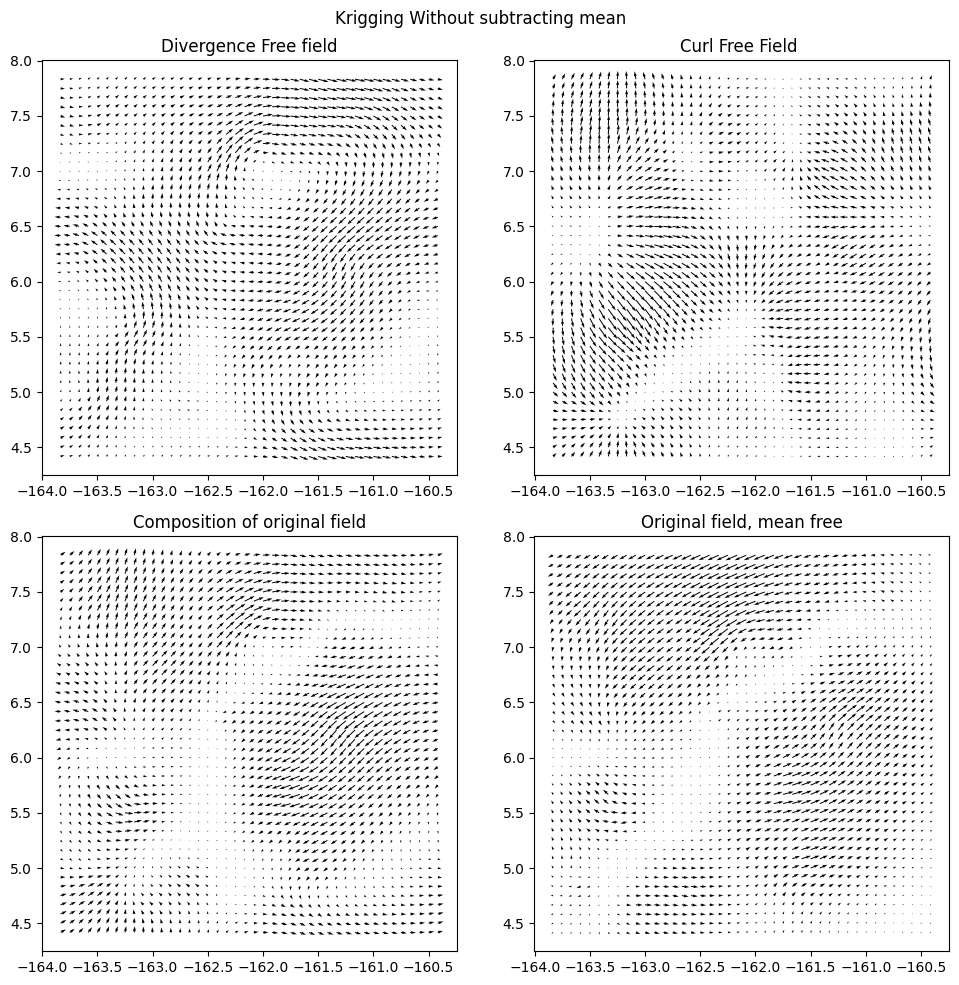

In [ ]:
##Calc Divergence free field, Curl Free field. 
target_date = pd.to_datetime("2025-6-13", format="%Y-%m-%d")
slice_t = ds.sel(time =target_date)
u = slice_t.uo.to_numpy()
v = slice_t.vo.to_numpy()
u_n = u - np.mean(u)
v_n = v - np.mean(v)
dx = haversine_dist(6.1, 163, 6.1, 163 +1/12) *1000



u_df, v_df, psi = helmholtz_div_free(u_n, v_n, dx,dx)
u_cf , v_cf ,phi = helmholtz_curl_free(u_n, v_n, dx,dx)

F_u = u_df + u_cf
F_v = v_df + v_cf

X, Y = np.meshgrid(slice_t.lon.to_numpy(), slice_t.lat.to_numpy())

fig, axs = plt.subplots(2,2, figsize = (10,10))
axs[0,0].quiver(X,Y,u_df, v_df )
axs[0,1].quiver(X,Y, u_cf, v_cf)
axs[1,0].quiver(X,Y, F_u, F_v)
axs[1,1].quiver(X,Y, u_n, v_n)

axs[0,0].set_title("Divergence Free field")
axs[0,1].set_title("Curl Free Field ")
axs[1,0].set_title("Composition of original field")
axs[1,1].set_title("Original field, mean free")

axs[0,0].set_box_aspect(1)
axs[0,1].set_box_aspect(1)
axs[1,0].set_box_aspect(1)
axs[1,1].set_box_aspect(1)

fig.suptitle("Krigging Without subtracting mean")
fig.tight_layout()



In [ ]:
print(np.gradient(X, axis = 1))

[[0.08332825 0.08332825 0.08333588 ... 0.08333588 0.08332825 0.08332825]
 [0.08332825 0.08332825 0.08333588 ... 0.08333588 0.08332825 0.08332825]
 [0.08332825 0.08332825 0.08333588 ... 0.08333588 0.08332825 0.08332825]
 ...
 [0.08332825 0.08332825 0.08333588 ... 0.08333588 0.08332825 0.08332825]
 [0.08332825 0.08332825 0.08333588 ... 0.08333588 0.08332825 0.08332825]
 [0.08332825 0.08332825 0.08333588 ... 0.08333588 0.08332825 0.08332825]]


In [ ]:
res_u = u_n - (u_df + u_cf)
res_v = v_n - (v_df + v_cf)
print("Max residual:", np.max(np.sqrt(res_u**2 + res_v**2)))

Max residual: 0.5384134195116497


### Without subtracting mean

2.051123196202181e-06 1.6696178845241382e-06


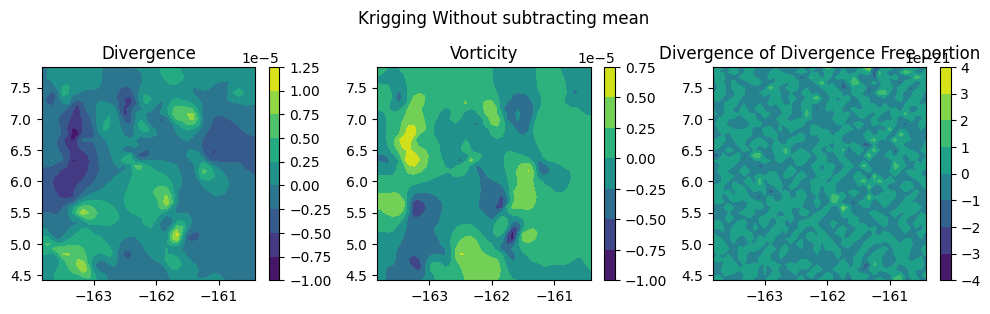

In [ ]:
target_date = pd.to_datetime("2025-6-13", format="%Y-%m-%d")
slice_t = ds.sel(time =target_date)

dx = haversine_dist(6.1, 163, 6.1, 163 +1/12) *1000

div = divergence(slice_t.uo, slice_t.vo, dx,dx, field = True)
vor = vorticity(slice_t.uo, slice_t.vo, dx,dx, field = True)
divv = divergence(slice_t.uo, slice_t.vo, dx,dx)
vorv = vorticity(slice_t.uo, slice_t.vo, dx,dx)
u_df, v_df, psi = helmholtz_div_free(slice_t.uo, slice_t.vo, dx,dx)
div_df = divergence(u_df, v_df, dx, dx, field = True)

X, Y = np.meshgrid(slice_t.lon.to_numpy(), slice_t.lat.to_numpy())
fig, ax = plt.subplots(1,3, figsize = (10,3))
c1 = ax[0].contourf(X,Y, div)
c2 = ax[1].contourf(X,Y, vor)
c3 = ax[2].contourf(X,Y, div_df)
fig.colorbar(c1, ax=ax[0])
fig.colorbar(c2, ax=ax[1])
fig.colorbar(c3, ax=ax[2])

ax[0].set_title("Divergence")
ax[1].set_title("Vorticity")
ax[2].set_title("Divergence of Divergence Free portion")
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)
ax[2].set_box_aspect(1)
fig.suptitle("Krigging Without subtracting mean")
fig.tight_layout()

fig.savefig(r"..\Figures\Divergence.png")

### Subtracting mean

2.051123196202181e-06 1.6696178845241382e-06


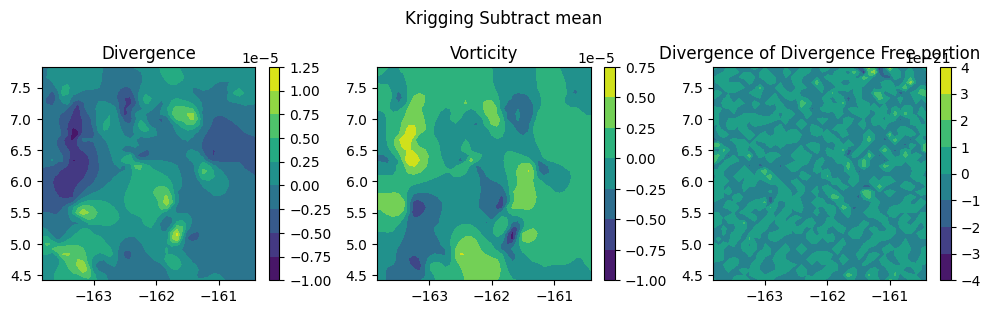

In [ ]:
um = slice_t.uo - np.mean(slice_t.uo)
vm = slice_t.vo - np.mean(slice_t.vo)


div = divergence(um, vm, dx,dx, field = True)
vor = vorticity(um, vm, dx,dx, field = True)
divv = divergence(um, vm, dx,dx)
vorv = vorticity(um, vm, dx,dx)
u_df, v_df, psi = helmholtz_div_free(um, vm, dx,dx)
div_df = divergence(u_df, v_df, dx, dx, field = True)

X, Y = np.meshgrid(slice_t.lon.to_numpy(), slice_t.lat.to_numpy())
fig, ax = plt.subplots(1,3, figsize = (10,3))
c1 = ax[0].contourf(X,Y, div)
c2 = ax[1].contourf(X,Y, vor)
c3 = ax[2].contourf(X,Y, div_df)
fig.colorbar(c1, ax=ax[0])
fig.colorbar(c2, ax=ax[1])
fig.colorbar(c3, ax=ax[2])

ax[0].set_title("Divergence")
ax[1].set_title("Vorticity")
ax[2].set_title("Divergence of Divergence Free portion")
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)
ax[2].set_box_aspect(1)
fig.suptitle("Krigging Subtract mean")
fig.tight_layout()
print(divv,vorv)
fig.savefig(r"..\Figures\Divergence_meanfree.png")

In [ ]:
## Plot Divergence Free, Curl Free field, reconstucted field (adding the two), original field


#### CMEMS

<xarray.DataArray 'uo' (latitude: 42, longitude: 42)> Size: 14kB
[1764 values with dtype=float64]
Coordinates:
    depth      float32 4B 15.81
  * latitude   (latitude) float32 168B 4.417 4.5 4.583 ... 7.667 7.75 7.833
  * longitude  (longitude) float32 168B -163.8 -163.8 -163.7 ... -160.5 -160.4
    time       datetime64[ns] 8B 2025-06-13
Attributes:
    units:          m s-1
    valid_min:      -3126
    standard_name:  eastward_sea_water_velocity
    long_name:      Eastward velocity
    unit_long:      Meters per second
    valid_max:      4296
6.485587637832267e-07 6.482395542005887e-07


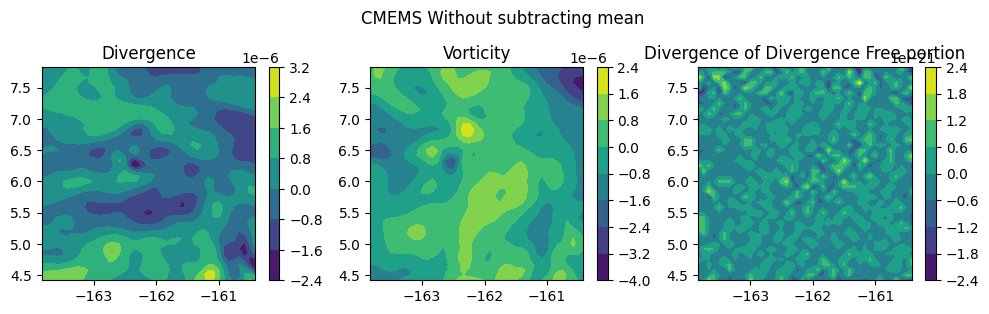

In [ ]:
cmems = xr.open_dataset("cmems.nc")
target_date = pd.to_datetime("2025-6-13", format="%Y-%m-%d")
slice_cm = cmems.sel(time =target_date, depth = 15, method = "nearest")

print(slice_cm.uo)
dx = haversine_dist(6.1, 163, 6.1, 163 +1/12) *1000

div = divergence(slice_cm.uo, slice_cm.vo, dx,dx, field = True)
vor = vorticity(slice_cm.uo, slice_cm.vo, dx,dx, field = True)
divv = divergence(slice_cm.uo, slice_cm.vo, dx,dx)
vorv = vorticity(slice_cm.uo, slice_cm.vo, dx,dx)
u_df, v_df, psi = helmholtz_div_free(slice_cm.uo, slice_cm.vo, dx,dx)
div_df = divergence(u_df, v_df, dx, dx, field = True)

X, Y = np.meshgrid(slice_t.lon.to_numpy(), slice_t.lat.to_numpy())
fig, ax = plt.subplots(1,3, figsize = (10,3))
c1 = ax[0].contourf(X,Y, div)
c2 = ax[1].contourf(X,Y, vor)
c3 = ax[2].contourf(X,Y, div_df)
fig.colorbar(c1, ax=ax[0])
fig.colorbar(c2, ax=ax[1])
fig.colorbar(c3, ax=ax[2])

ax[0].set_title("Divergence")
ax[1].set_title("Vorticity")
ax[2].set_title("Divergence of Divergence Free portion")
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)
ax[2].set_box_aspect(1)
fig.suptitle("CMEMS Without subtracting mean")
fig.tight_layout()
print(divv,vorv)
fig.savefig(r"..\Figures\Divergence_cmems.png")

### Subtracting mean

6.485587637832267e-07 6.482395542005886e-07


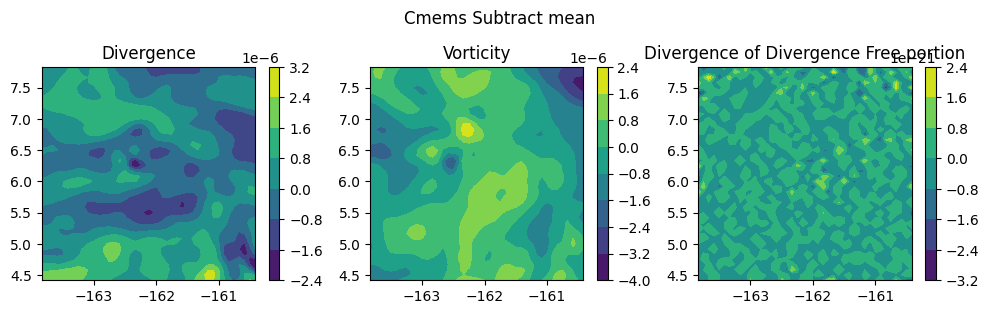

In [ ]:
um = slice_cm.uo - np.mean(slice_cm.uo)
vm = slice_cm.vo - np.mean(slice_cm.vo)


div = divergence(um, vm, dx,dx, field = True)
vor = vorticity(um, vm, dx,dx, field = True)
divv = divergence(um, vm, dx,dx)
vorv = vorticity(um, vm, dx,dx)
u_df, v_df, psi = helmholtz_div_free(um, vm, dx,dx)
div_df = divergence(u_df, v_df, dx, dx, field = True)

X, Y = np.meshgrid(slice_t.lon.to_numpy(), slice_t.lat.to_numpy())
fig, ax = plt.subplots(1,3, figsize = (10,3))
c1 = ax[0].contourf(X,Y, div)
c2 = ax[1].contourf(X,Y, vor)
c3 = ax[2].contourf(X,Y, div_df)
fig.colorbar(c1, ax=ax[0])
fig.colorbar(c2, ax=ax[1])
fig.colorbar(c3, ax=ax[2])

ax[0].set_title("Divergence")
ax[1].set_title("Vorticity")
ax[2].set_title("Divergence of Divergence Free portion")
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)
ax[2].set_box_aspect(1)
fig.suptitle("Cmems Subtract mean ")
fig.tight_layout()
print(divv,vorv)
fig.savefig(r"..\Figures\Divergence_meanfree_cmems.png")

## derivative Operators 

In [ ]:
import numpy as np
import scipy.sparse as sp
def build_operators_dirichlet_top(szY, szZ, dy, dz):
    # A and B as in MATLAB
    A = np.column_stack([
    -1.0 * np.ones(szY),
    16.0 * np.ones(szY),
    -30.0 * np.ones(szY),
    16.0 * np.ones(szY),
    -1.0 * np.ones(szY),
    ])
    B = np.column_stack([
    np.ones(szY),
    -8.0 * np.ones(szY),
    np.zeros(szY),
    8.0 * np.ones(szY),
    -1.0 * np.ones(szY),
    ])
    K2y = (1.0 / (12.0 * dy**2)) * sp.spdiags(A.T, [-2, -1, 0, 1, 2], szY, szY)
    K1y = (1.0 / (12.0 * dy)) * sp.spdiags(B.T, [-2, -1, 0, 1, 2], szY, szY)
    Dy = sp.kron(sp.eye(szZ, format="csr"), K1y, format="csr")
    Dyy = sp.kron(sp.eye(szZ, format="csr"), K2y, format="csr")
    # z: B = fliplr(B);
    #Bz = np.fliplr(B) % no flip needed?
    Bz=B
    K1z = (1.0 / (12.0 * dz)) * sp.spdiags(Bz.T, [-2, -1, 0, 1, 2], szZ, szZ)
    K2z = (1.0 / (12.0 * dz**2)) * sp.spdiags(A.T, [-2, -1, 0, 1, 2], szZ, szZ)
    Dz = sp.kron(K1z, sp.eye(szY, format="csr"), format="csr")
    Dzz = sp.kron(K2z, sp.eye(szY, format="csr"), format="csr")
    return Dy, Dyy, Dz, Dzz
def stack2d(X):
    """Stack a 2-D array (nyxnx) into a 1-D column vector (ny*nx,)."""
    return X.ravel(order='C') # row-major flattening (consistent with your def unstack2d(v, ny, nx):

def unstack2d(v, ny, nx):
    """Unstack a 1-D vector into a 2-D array (nyxnx)."""
    return np.reshape(v, (ny, nx), order='C')

2.6945495065913683e-06


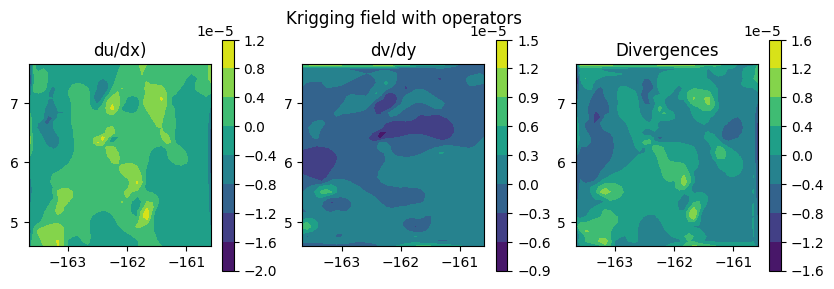

In [ ]:
slice_t = ds.sel(time =target_date)
u = slice_t.uo.to_numpy()
v = slice_t.vo.to_numpy()
u_n = u- np.mean(u)
v_n= v - np.mean(v)
u_int = u_n[2:-2,2:-2]
v_int = v_n[2:-2,2:-2]

dx = haversine_dist(6.1, 163, 6.1, 163 +1/12) *1000

n,m = u_int.shape
Dx,Dxx,Dy,Dyy = build_operators_dirichlet_top(n,m,dx,dx)
dx_u = Dx@stack2d(u_int)
dy_v = Dy@stack2d(v_int)
dx_u = unstack2d(dx_u, n,m)
dy_v = unstack2d(dy_v, n,m )
divergencecalc = dx_u + dy_v

lats = slice_t.lon.to_numpy()
lons = slice_t.lat.to_numpy()
X, Y = np.meshgrid(lats[2:-2], lons[2:-2])
fig, ax = plt.subplots(1,3, figsize = (10,3))
c1 = ax[0].contourf(X,Y, dx_u)
c2 = ax[1].contourf(X,Y, dy_v)
c3 = ax[2].contourf(X,Y, divergencecalc)
print(np.mean(np.abs(divergencecalc)))
fig.suptitle("Krigging field with operators")
ax[0].set_title("du/dx)")
ax[1].set_title("dv/dy")
ax[2].set_title("Divergences")
fig.colorbar(c1)
fig.colorbar(c2)
fig.colorbar(c3)
ax[0].set_box_aspect(1)
ax[1].set_box_aspect(1)
ax[2].set_box_aspect(1)
fig.savefig("../Figures/Divergence_Operators_krigging.png")

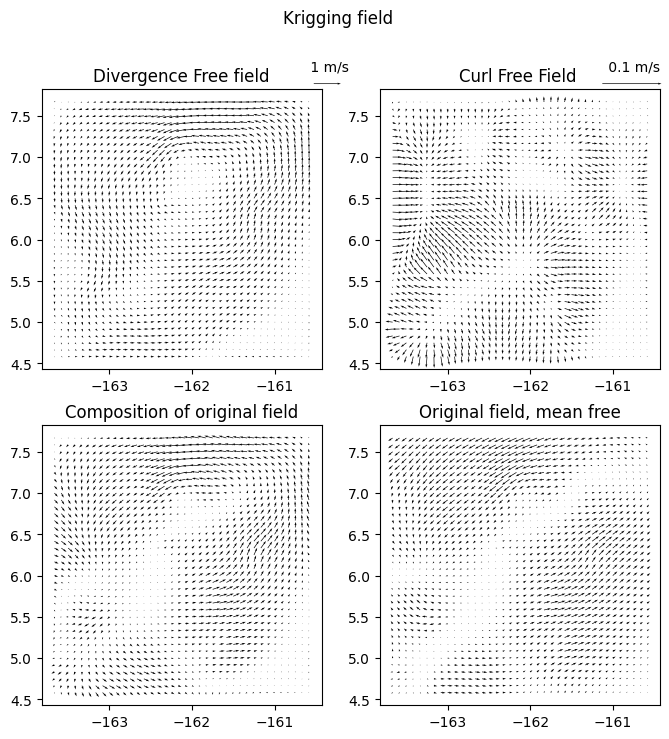

In [ ]:
## Solve divergence free, Curl free, and reconstruct original
##starting with u_int and v_int which are internal velosities
from scipy.sparse.linalg import spsolve
## Div free 

dx_v = Dx@stack2d(v_int)
dy_u = Dy@stack2d(u_int)
vorticity  = dx_v - dy_u

LG2 = Dxx +Dyy 
psi = spsolve(LG2, -vorticity)

u_df = Dy@psi
v_df = -Dx@psi
u_df = unstack2d(u_df,n,m)
v_df = unstack2d(v_df,n,m)

## Curl free, potential
dx_u = Dx@stack2d(u_int)
dy_v = Dy@stack2d(v_int)

div = dx_u + dy_v

pV = spsolve(LG2, div)

u_cf = unstack2d(Dx@pV, n,m)
v_cf = unstack2d(Dy@pV,n,m)

u_recon = u_df + u_cf
v_recon = v_df + v_cf 


X, Y = np.meshgrid(lats[2:-2], lons[2:-2])
fig, axs = plt.subplots(2,2, figsize = (8,8))
q0 = axs[0,0].quiver(X,Y,u_df,v_df)
q1 = axs[0,1].quiver(X,Y,u_cf, v_cf)
q2 = axs[1,0].quiver(X,Y, u_recon, v_recon)
q3 = axs[1,1].quiver(X,Y, u_int, v_int)

axs[0,0].quiverkey(q0, 1.02, 1.02, 1, label = " 1 m/s", coordinates = "axes")
axs[0,1].quiverkey(q1, 0.9, 1.02, 1, label = " 0.1 m/s", coordinates = "axes")


axs[0,0].set_title("Divergence Free field")
axs[0,1].set_title("Curl Free Field ")
axs[1,0].set_title("Composition of original field")
axs[1,1].set_title("Original field, mean free")

axs[0,0].set_box_aspect(1)
axs[0,1].set_box_aspect(1)
axs[1,0].set_box_aspect(1)
axs[1,1].set_box_aspect(1)
fig.suptitle("Krigging field ")
fig.savefig("../Figures/Divergence_operaters_loop.png" )



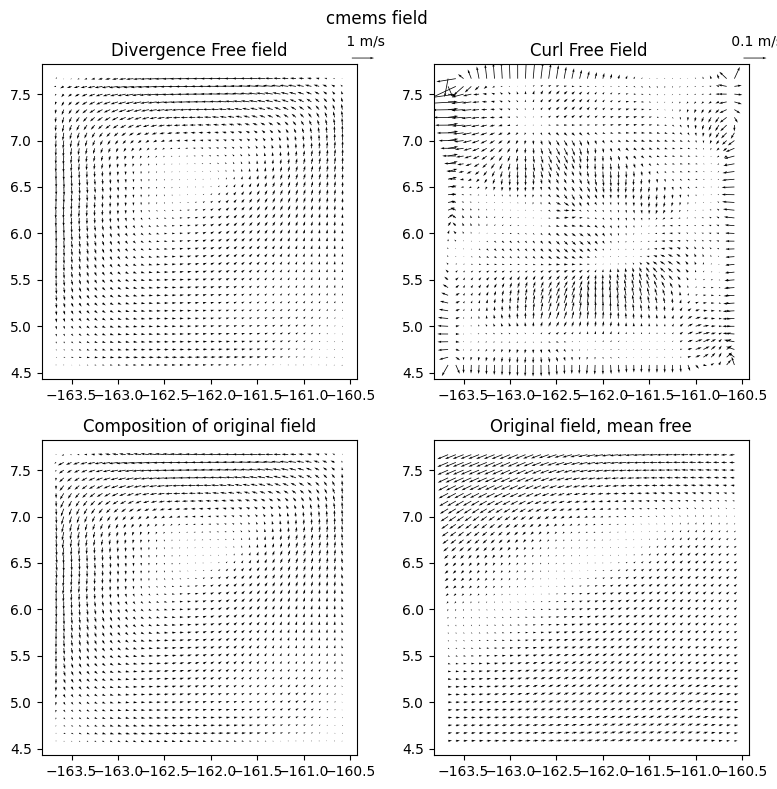

In [ ]:
cmems = xr.open_dataset("cmems.nc")
target_date = pd.to_datetime("2025-6-13", format="%Y-%m-%d")
slice_t = cmems.sel(time =target_date, depth = 15, method = "nearest")
u = slice_t.uo.to_numpy()
v = slice_t.vo.to_numpy()

u_n = u- np.mean(u)
v_n= v - np.mean(v)
u_int = u_n[2:-2,2:-2]
v_int = v_n[2:-2,2:-2]
n,m = u_int.shape

dx_v = Dx@stack2d(v_int)
dy_u = Dy@stack2d(u_int)
vorticity  = dx_v - dy_u

LG2 = Dxx +Dyy 
psi = spsolve(LG2, -vorticity)

u_df = Dy@psi
v_df = -Dx@psi
u_df = unstack2d(u_df,n,m)
v_df = unstack2d(v_df,n,m)

## Curl free, potential
dx_u = Dx@stack2d(u_int)
dy_v = Dy@stack2d(v_int)

div = dx_u + dy_v

pV = spsolve(LG2, div)

u_cf = unstack2d(Dx@pV, n,m)
v_cf = unstack2d(Dy@pV,n,m)

u_recon = u_df + u_cf
v_recon = v_df + v_cf 


X, Y = np.meshgrid(lats[2:-2], lons[2:-2])
fig, axs = plt.subplots(2,2, figsize = (8,8))
q0 = axs[0,0].quiver(X,Y,u_df,v_df)
q1 = axs[0,1].quiver(X,Y,u_cf, v_cf)
q2 = axs[1,0].quiver(X,Y, u_recon, v_recon)
q3 = axs[1,1].quiver(X,Y, u_int, v_int)

axs[0,0].quiverkey(q0, 1.02, 1.02, 1, label = " 1 m/s", coordinates = "axes")
axs[0,1].quiverkey(q1, 1.02, 1.02, 0.1, label = " 0.1 m/s", coordinates = "axes")

axs[0,0].set_title("Divergence Free field")
axs[0,1].set_title("Curl Free Field ")
axs[1,0].set_title("Composition of original field")
axs[1,1].set_title("Original field, mean free")

axs[0,0].set_box_aspect(1)
axs[0,1].set_box_aspect(1)
axs[1,0].set_box_aspect(1)
axs[1,1].set_box_aspect(1)
fig.suptitle("cmems field ")
fig.tight_layout()
fig.savefig("../Figures/Divergence_operaters_loop_cmems.png" )







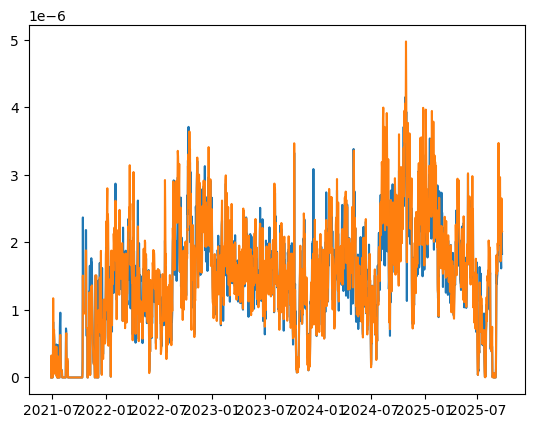

In [ ]:
dx = haversine_dist(6.1, 163, 6.1, 163 +1/12) *1000

divergences = []
vorticities = []

for each in ds.time: 
    slice_t  = ds.sel(time =each)
    divergences.append(divergence(slice_t.uo, slice_t.vo, dx,dx))
    vorticities.append(vorticity(slice_t.uo, slice_t.vo, dx,dx))

fig, ax = plt.subplots()
ax.plot(ds.time, np.abs(divergences), label = "divergence")
ax.plot(ds.time, np.abs(vorticities), label = "vorticity")


In [ ]:
x = np.array(([1,2,3,4], [5,6,7,8,]))
x.ravel("c")

array([1, 2, 3, 4, 5, 6, 7, 8])

## Testing Krigging Itself, Can it produce a krigging field 

In [213]:
dsn = pd.read_csv("Data/krigging_test_stats_nsamples.csv")
dsn.columns
print(dsn.velomax) ## cmems max speed is 0.739472

0      0.778835
1      0.759026
2      0.770565
3      0.775588
4      0.742833
         ...   
194    0.789184
195    0.790318
196    0.780412
197    0.795844
198    0.790318
Name: velomax, Length: 199, dtype: float64


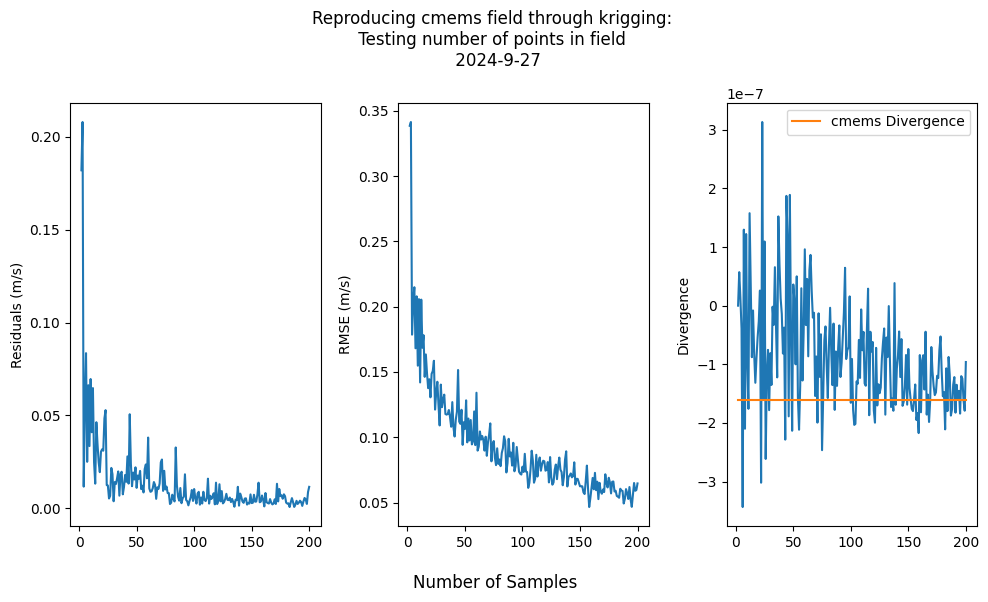

In [214]:
fig, ax = plt.subplots(1,3, figsize = (10,6))
ax[0].plot(dsn.samples, np.sqrt(dsn.ru**2 + dsn.rv**2))
ax[1].plot(dsn.samples, np.sqrt(dsn.rmseu**2 + dsn.rmsev**2))
ax[2].plot(dsn.samples, (dsn.krig_div))
ax[2].plot(dsn.samples, dsn.cmems_div, label = "cmems Divergence")
ax[2].plot()
fig.supxlabel("Number of Samples")
fig.suptitle("Reproducing cmems field through krigging: \n Testing number of points in field  \n 2024-9-27")
ax[0].set_ylabel("Residuals (m/s)")

ax[1].set_ylabel("RMSE (m/s)")
ax[2].set_ylabel("Divergence")
ax[2].legend()

fig.tight_layout()


In [207]:
ds40 = pd.read_csv("Data/krigging_test_stats.csv")
ds40 = ds40.rename(columns = {"Unnamed: 0": "Testnumber"})
ds40["r"] = (np.sqrt(ds40.ru**2 + ds40.rv**2))
var_r = np.var(ds40.r)
mean_r = (np.sqrt(ds40.ru**2 + ds40.rv**2)).mean()
div_mean = np.mean(ds40.krig_div)
ds40.columns

Index(['Testnumber', 'ru', 'rv', 'rmseu', 'rmsev', 'cmems_div', 'krig_div',
       'velomax', 'r'],
      dtype='object')

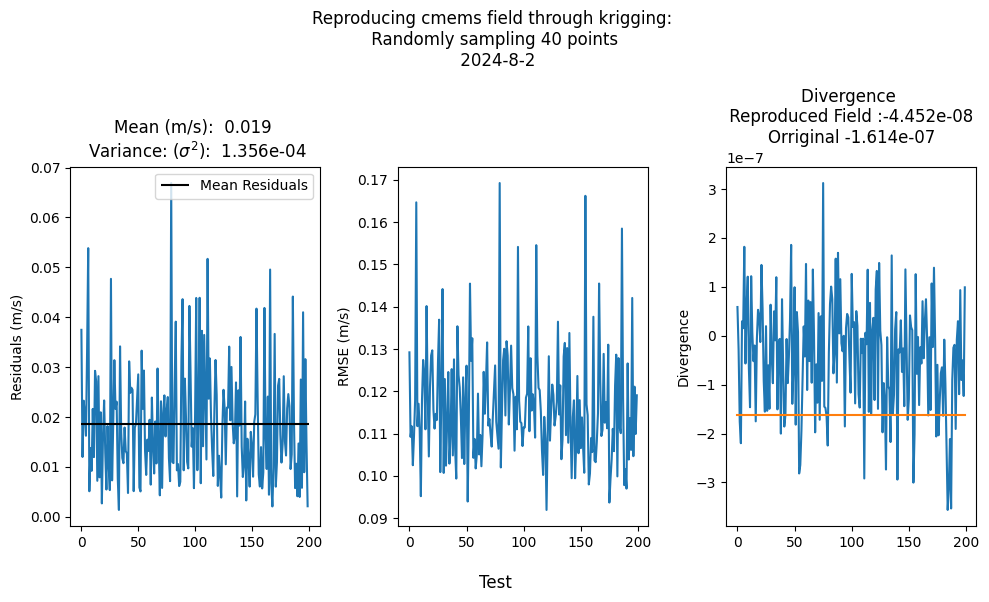

In [ ]:
fig, ax = plt.subplots(1,3, figsize = (10,6))
ax[0].plot(ds40["Testnumber"], np.sqrt(ds40.ru**2 + ds40.rv**2))
ax[0].hlines(mean_r, xmin = 0, xmax = len(ds40), color = "k", label = "Mean Residuals")
ax[1].plot(ds40["Testnumber"], np.sqrt(ds40.rmseu**2 + ds40.rmsev**2))
ax[2].plot(ds40["Testnumber"], (ds40.krig_div))
ax[2].plot(ds40["Testnumber"], ds40.cmems_div, label = "cmems Divergence")
ax[2].plot()
fig.supxlabel("Test")
fig.suptitle("Reproducing cmems field through krigging: \n Randomly sampling 40 points \n 2024-9-27")


ax[0].set_ylabel("Residuals (m/s)")
ax[0].set_title(fr"Mean (m/s): {mean_r: .3f} {"\n"} Variance: ($\sigma^2$): {var_r: 0.3e}") #
ax[1].set_ylabel("RMSE (m/s)")
ax[2].set_ylabel("Divergence")
ax[2].set_title(f"Divergence \n Reproduced Field :{div_mean:0.3e} \nOrriginal {ds40.cmems_div[0]: 0.3e}")
ax[0].legend()

fig.tight_layout()

In [217]:
dsd= pd.read_csv("Data/krigging_test_stats_days.csv")
timerange = pd.date_range("2024-1-1", "2024-12-31")
dsd["date"] = timerange
dsd["r"] = (np.sqrt(dsd.ru**2 + dsd.rv**2))
dsd["rmse"] = np.sqrt(dsd.rmseu**2 + dsd.rmsev**2)
var_r = np.var(dsd.r)
mean_r = (np.sqrt(dsd.ru**2 + dsd.rv**2)).mean()
div_cor = (np.corrcoef(dsd.cmems_div, dsd.krig_div)[0,1])
dsd["r_rm"]= Rolling_mean(dsd["r"].to_list(), 7)
dsd["rmse_rm"] = Rolling_mean(dsd["rmse"].to_list(), 7)
dsd["cmems_div_rm"] = Rolling_mean(dsd["cmems_div"].to_list(), 7)
dsd["krig_div_rm"] = Rolling_mean(dsd["krig_div"].to_list(), 7)


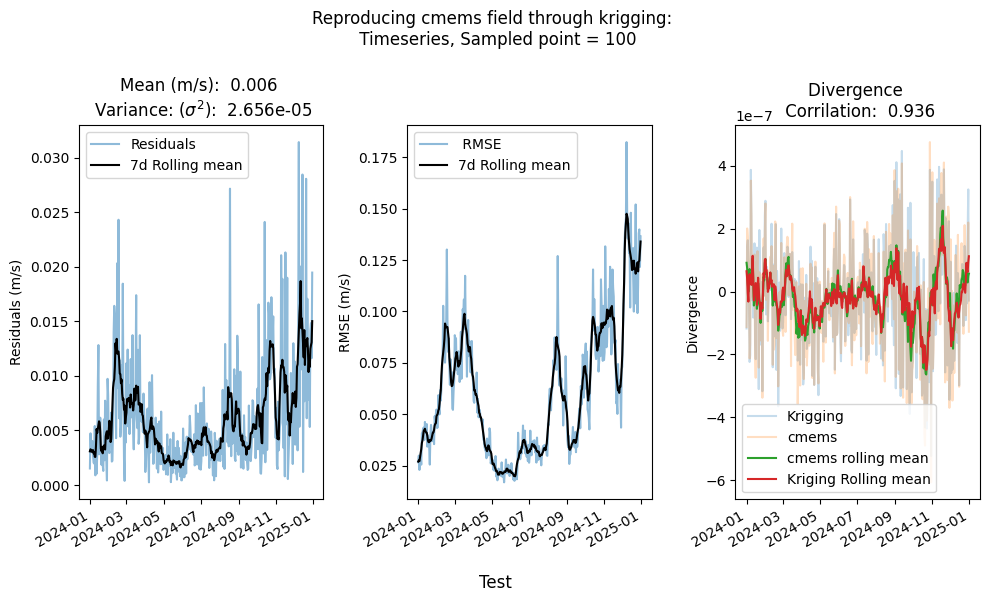

In [223]:
fig, ax = plt.subplots(1,3, figsize = (10,6))
ax[0].plot(dsd["date"], np.sqrt(dsd.ru**2 + dsd.rv**2), alpha = 0.5, label = "Residuals")
ax[0].plot(dsd['date'], dsd.r_rm, label = "7d Rolling mean", color = "k")
#ax[0].hlines(mean_r, xmin = 0, xmax = len(dsd), color = "k", label = "Mean Residuals")
ax[1].plot(dsd["date"], np.sqrt(dsd.rmseu**2 + dsd.rmsev**2), alpha = 0.5, label = " RMSE")
ax[1].plot(dsd["date"], dsd.rmse_rm, label = "7d Rolling mean", color = "k")
ax[2].plot(dsd["date"], (dsd.krig_div), alpha = 0.25, label = "Krigging")
ax[2].plot(dsd["date"], dsd.cmems_div, label = "cmems", alpha = 0.25)
ax[2].plot(dsd["date"], dsd.cmems_div_rm, label = "cmems rolling mean")
ax[2].plot(dsd["date"], dsd.krig_div_rm, label = "Kriging Rolling mean")
fig.supxlabel("Test")
fig.suptitle("Reproducing cmems field through krigging: \n Timeseries, Sampled point = 100")


ax[0].set_ylabel("Residuals (m/s)")
ax[0].set_title(fr"Mean (m/s): {mean_r: .3f} {"\n"} Variance: ($\sigma^2$): {var_r: 0.3e}") #
ax[1].set_ylabel("RMSE (m/s)")
ax[2].set_ylabel("Divergence")
ax[2].set_title(fr"Divergence {"\n"} Corrilation: {div_cor: 0.3f}")
ax[0].legend()
ax[1].legend()
ax[2].legend()
#ax[2].set_xlim(timerange[100], timerange[120])
# ax[1].set_xlim(timerange[0], timerange[30])
# ax[0].set_xlim(timerange[0], timerange[30])

fig.autofmt_xdate()
fig.tight_layout()